In [25]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

sns.set_theme(style='whitegrid')

# -----------------------------
# 1) Load data
# -----------------------------
file_path = Path('../../data/player_profiles/player_profiles.parquet')

if not file_path.exists():
    raise FileNotFoundError(f"Could not find file at: {file_path.resolve()}")


In [26]:
df = pl.read_parquet(file_path)

print('Loaded player profile dataset')
print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')

# -----------------------------
# 2) Basic data checks
# -----------------------------
print('\n=== BASIC INFO ===')
print('Schema:')
for col_name, dtype in df.schema.items():
    print(f'  - {col_name}: {dtype}')


Loaded player profile dataset
Shape: (5, 19)
Columns: 19

=== BASIC INFO ===
Schema:
  - player: String
  - num_games: UInt32
  - avg_turns_before_first_trade: Float64
  - ratio_cards_given_to_taken: Float64
  - trade_success_rate: Float64
  - avg_counter_offers: Float64
  - avg_bank_trades: Float64
  - avg_dev_cards_bought: Float64
  - avg_roads_built: Float64
  - avg_cities_built: Float64
  - avg_players_targeted: Float64
  - avg_times_targeted: Float64
  - avg_cards_discarded_to_7: Float64
  - win_rate_largest_army: Float64
  - win_rate_longest_road: Float64
  - overall_avg_hand_size: Float64
  - top_3_starting_resources: String
  - most_traded_away_resource: String
  - most_received_resource: String


In [27]:
print('\nFirst 5 rows:')
display(df.head(5))

print('\n=== SUMMARY STATS (describe) ===')
print(df.describe())



First 5 rows:


player,num_games,avg_turns_before_first_trade,ratio_cards_given_to_taken,trade_success_rate,avg_counter_offers,avg_bank_trades,avg_dev_cards_bought,avg_roads_built,avg_cities_built,avg_players_targeted,avg_times_targeted,avg_cards_discarded_to_7,win_rate_largest_army,win_rate_longest_road,overall_avg_hand_size,top_3_starting_resources,most_traded_away_resource,most_received_resource
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""HomeofAD3005""",11,11.181818,0.930233,0.207792,3.272727,5.727273,2.272727,7.636364,1.727273,2.181818,0.0,0.0,0.090909,0.545455,6.41842,"""lumber, grain, brick""","""wool""","""ore"""
"""Romeoore""",7,11.714286,1.026316,0.191781,3.0,3.571429,6.0,6.0,1.857143,2.285714,0.0,0.0,0.714286,0.142857,6.069925,"""grain, wool, ore""","""lumber""","""ore"""
"""ZL24""",6,10.0,1.25,0.4375,1.0,5.0,4.666667,6.5,2.833333,0.5,3.833333,0.0,0.166667,0.166667,6.43097,"""lumber, wool, grain""","""brick""","""grain"""
"""AatNeverLose""",5,13.2,1.176471,0.2,0.0,3.6,4.0,8.0,1.8,1.8,0.0,0.0,0.2,0.0,7.253332,"""grain, lumber, brick""","""lumber""","""wool"""
"""UniQueLagacy""",5,9.6,1.04,0.174603,2.0,4.8,2.2,7.6,1.6,1.8,0.0,0.0,0.0,0.6,8.463008,"""grain, brick, wool""","""lumber""","""ore"""



=== SUMMARY STATS (describe) ===
shape: (9, 20)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ player    ┆ num_games ┆ avg_turns ┆ … ┆ overall_a ┆ top_3_sta ┆ most_trad ┆ most_rec │
│ ---       ┆ ---       ┆ ---       ┆ _before_f ┆   ┆ vg_hand_s ┆ rting_res ┆ ed_away_r ┆ eived_re │
│ str       ┆ str       ┆ f64       ┆ irst_trad ┆   ┆ ize       ┆ ources    ┆ esource   ┆ source   │
│           ┆           ┆           ┆ e         ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆ ---       ┆   ┆ f64       ┆ str       ┆ str       ┆ str      │
│           ┆           ┆           ┆ f64       ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 5         ┆ 5.0       ┆ 5.0       ┆ … ┆ 5.0       ┆ 5         ┆ 5         ┆ 5        │
│ null_coun ┆ 0         ┆ 0.0       ┆ 0.0 

In [28]:
print('\n=== MISSING VALUES (NULL) ===')
null_counts = df.null_count().transpose(include_header=True, header_name='column', column_names=['null_count'])
print(null_counts.sort('null_count', descending=True))

print('\n=== MISSING VALUES (NaN) ===')
float_cols = [c for c, dt in df.schema.items() if dt in (pl.Float32, pl.Float64)]
if float_cols:
    nan_counts = df.select([
        pl.col(c).is_nan().sum().alias(c) for c in float_cols
    ]).transpose(include_header=True, header_name='column', column_names=['nan_count'])
    print(nan_counts.sort('nan_count', descending=True))
else:
    print('No float columns found; skipping NaN check.')



=== MISSING VALUES (NULL) ===
shape: (19, 2)
┌──────────────────────────────┬────────────┐
│ column                       ┆ null_count │
│ ---                          ┆ ---        │
│ str                          ┆ u32        │
╞══════════════════════════════╪════════════╡
│ player                       ┆ 0          │
│ num_games                    ┆ 0          │
│ avg_turns_before_first_trade ┆ 0          │
│ ratio_cards_given_to_taken   ┆ 0          │
│ trade_success_rate           ┆ 0          │
│ …                            ┆ …          │
│ win_rate_longest_road        ┆ 0          │
│ overall_avg_hand_size        ┆ 0          │
│ top_3_starting_resources     ┆ 0          │
│ most_traded_away_resource    ┆ 0          │
│ most_received_resource       ┆ 0          │
└──────────────────────────────┴────────────┘

=== MISSING VALUES (NaN) ===
shape: (14, 2)
┌──────────────────────────────┬───────────┐
│ column                       ┆ nan_count │
│ ---                          ┆ --- 

In [29]:
# -----------------------------
# 3) Data cleaning + ML prep
# -----------------------------
# Drop rows where player is null (identity key)
df_clean = df.filter(pl.col('player').is_not_null())

# Separate feature types
exclude_from_features = {'player'}
feature_cols = [c for c in df_clean.columns if c not in exclude_from_features]

numeric_cols = [
    c for c in feature_cols
    if df_clean.schema[c] in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    )
]

categorical_cols = [
    c for c in feature_cols
    if df_clean.schema[c] in (pl.Utf8, pl.Categorical)
]

print('\n=== FEATURE SPLIT ===')
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')



=== FEATURE SPLIT ===
Numeric columns (15): ['num_games', 'avg_turns_before_first_trade', 'ratio_cards_given_to_taken', 'trade_success_rate', 'avg_counter_offers', 'avg_bank_trades', 'avg_dev_cards_bought', 'avg_roads_built', 'avg_cities_built', 'avg_players_targeted', 'avg_times_targeted', 'avg_cards_discarded_to_7', 'win_rate_largest_army', 'win_rate_longest_road', 'overall_avg_hand_size']
Categorical columns (3): ['top_3_starting_resources', 'most_traded_away_resource', 'most_received_resource']


In [30]:
# Impute numeric nulls with median
if numeric_cols:
    numeric_impute_exprs = [
        pl.when(pl.col(c).is_null())
          .then(pl.col(c).median())
          .otherwise(pl.col(c))
          .alias(c)
        for c in numeric_cols
    ]
    df_clean = df_clean.with_columns(numeric_impute_exprs)

# Impute categorical nulls with 'Unknown'
if categorical_cols:
    cat_impute_exprs = [pl.col(c).fill_null('Unknown').alias(c) for c in categorical_cols]
    df_clean = df_clean.with_columns(cat_impute_exprs)

# One-hot encode categorical features
# Keep player as identifier in a separate dataframe for downstream joins/inspection
df_ml = df_clean.select(['player'] + numeric_cols + categorical_cols)

# Special handling: top_3_starting_resources is multi-label (e.g., "grain, lumber, brick")
# It should become separate binary flags per resource instead of one combined category.
resource_list_col = 'top_3_starting_resources'
if resource_list_col in df_ml.columns:
    resource_values = ['ore', 'wool', 'lumber', 'grain', 'brick']
    resource_exprs = [
        pl.when(
            pl.col(resource_list_col)
              .str.to_lowercase()
              .str.contains(rf'(^|,\s*){res}(\s*,|$)')
        )
        .then(1)
        .otherwise(0)
        .alias(f'starting_resource_{res}')
        for res in resource_values
    ]
    df_ml = df_ml.with_columns(resource_exprs).drop(resource_list_col)

# Standard one-hot for remaining categorical features (excluding special multi-label column)
remaining_categorical_cols = [
    c for c in categorical_cols
    if c != resource_list_col and c in df_ml.columns
]
if remaining_categorical_cols:
    df_ml = df_ml.to_dummies(columns=remaining_categorical_cols, separator='__')

# Standardize numeric columns (z-score) for ML readiness
# We do this after dummies so numeric columns include engineered binary columns as needed.
# For stability: if std = 0, return 0.0
ml_numeric_cols = [
    c for c, dt in df_ml.schema.items()
    if c != 'player' and dt in (
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
        pl.Float32, pl.Float64
    )
]

scaled_exprs = []
for c in ml_numeric_cols:
    mean_expr = pl.col(c).mean()
    std_expr = pl.col(c).std()
    scaled_exprs.append(
        pl.when(std_expr.is_null() | (std_expr == 0))
          .then(0.0)
          .otherwise((pl.col(c) - mean_expr) / std_expr)
          .alias(f'{c}__z')
    )

df_ml_ready = df_ml.with_columns(scaled_exprs)

print('\n=== ML-READY DATA ===')
print(f'ML dataset shape: {df_ml_ready.shape}')
print('Preview:')
display(df_ml_ready.head(5))



=== ML-READY DATA ===
ML dataset shape: (5, 53)
Preview:


player,num_games,avg_turns_before_first_trade,ratio_cards_given_to_taken,trade_success_rate,avg_counter_offers,avg_bank_trades,avg_dev_cards_bought,avg_roads_built,avg_cities_built,avg_players_targeted,avg_times_targeted,avg_cards_discarded_to_7,win_rate_largest_army,win_rate_longest_road,overall_avg_hand_size,most_traded_away_resource__brick,most_traded_away_resource__lumber,most_traded_away_resource__wool,most_received_resource__grain,most_received_resource__ore,most_received_resource__wool,starting_resource_ore,starting_resource_wool,starting_resource_lumber,starting_resource_grain,starting_resource_brick,num_games__z,avg_turns_before_first_trade__z,ratio_cards_given_to_taken__z,trade_success_rate__z,avg_counter_offers__z,avg_bank_trades__z,avg_dev_cards_bought__z,avg_roads_built__z,avg_cities_built__z,avg_players_targeted__z,avg_times_targeted__z,avg_cards_discarded_to_7__z,win_rate_largest_army__z,win_rate_longest_road__z,overall_avg_hand_size__z,most_traded_away_resource__brick__z,most_traded_away_resource__lumber__z,most_traded_away_resource__wool__z,most_received_resource__grain__z,most_received_resource__ore__z,most_received_resource__wool__z,starting_resource_ore__z,starting_resource_wool__z,starting_resource_lumber__z,starting_resource_grain__z,starting_resource_brick__z
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HomeofAD3005""",11.0,11.181818,0.930233,0.207792,3.272727,5.727273,2.272727,7.636364,1.727273,2.181818,0.0,0.0,0.090909,0.545455,6.41842,0,0,1,0,1,0,0,0,1,1,1,1.686761,0.029668,-1.210868,-0.314619,1.034725,1.267617,-0.958957,0.573764,-0.476722,0.656686,-0.447214,0.0,-0.514015,0.957814,-0.528569,-0.447214,-1.095445,1.788854,-0.447214,0.730297,-0.447214,-0.447214,-1.095445,0.730297,0.0,0.730297
"""Romeoore""",7.0,11.714286,1.026316,0.191781,3.0,3.571429,6.0,6.0,1.857143,2.285714,0.0,0.0,0.714286,0.142857,6.069925,0,1,0,0,1,0,1,1,0,1,0,0.080322,0.400512,-0.457203,-0.460451,0.835739,-1.033613,1.339401,-1.345893,-0.214691,0.802373,-0.447214,0.0,1.719484,-0.557611,-0.890668,-0.447214,0.730297,-0.447214,-0.447214,0.730297,-0.447214,1.788854,0.730297,-1.095445,0.0,-1.095445
"""ZL24""",6.0,10.0,1.25,0.4375,1.0,5.0,4.666667,6.5,2.833333,0.5,3.833333,0.0,0.166667,0.166667,6.43097,1,0,0,1,0,0,0,1,1,1,0,-0.321288,-0.793427,1.297346,1.777567,-0.623488,0.491299,0.517224,-0.759331,1.754911,-1.701629,1.788854,0.0,-0.242583,-0.467989,-0.515529,1.788854,-1.095445,-0.447214,1.788854,-1.095445,-0.447214,-0.447214,0.730297,0.730297,0.0,-1.095445
"""AatNeverLose""",5.0,13.2,1.176471,0.2,0.0,3.6,4.0,8.0,1.8,1.8,0.0,0.0,0.2,0.0,7.253332,0,1,0,0,0,1,0,0,1,1,1,-0.722897,1.43526,0.720591,-0.385591,-1.353102,-1.003114,0.106136,1.000355,-0.329985,0.121285,-0.447214,0.0,-0.123153,-1.095343,0.338935,-0.447214,0.730297,-0.447214,-0.447214,-1.095445,1.788854,-0.447214,-1.095445,0.730297,0.0,0.730297
"""UniQueLagacy""",5.0,9.6,1.04,0.174603,2.0,4.8,2.2,7.6,1.6,1.8,0.0,0.0,0.0,0.6,8.463008,0,1,0,0,1,0,0,1,0,1,1,-0.722897,-1.072013,-0.349866,-0.616906,0.106126,0.277811,-1.003803,0.531105,-0.733513,0.121285,-0.447214,0.0,-0.839733,1.16313,1.595831,-0.447214,0.730297,-0.447214,-0.447214,0.730297,-0.447214,-0.447214,0.730297,-1.095445,0.0,0.730297


In [31]:
# Optional: save ML-ready dataset
# ml_output_path = Path('../../data/player_profiles/player_profiles_ml_ready.parquet')
# df_ml_ready.write_parquet(ml_output_path)
# print(f"Saved ML-ready dataset to: {ml_output_path}")


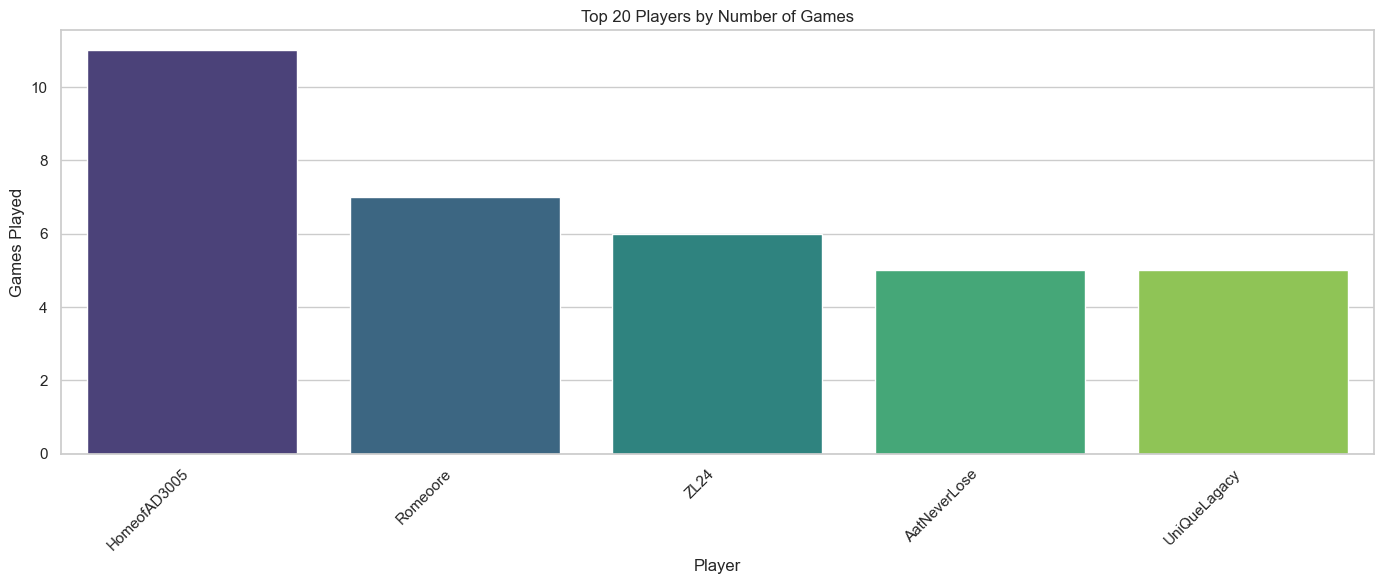

In [32]:
# -----------------------------
# 4) Basic profile visualizations
# -----------------------------
plot_df = df_clean.to_pandas()

# A) Top players by games played
if 'num_games' in plot_df.columns:
    top_games_df = plot_df.sort_values('num_games', ascending=False).head(20)

    plt.figure(figsize=(14, 6))
    sns.barplot(data=top_games_df, x='player', y='num_games', hue='player', dodge=False, legend=False, palette='viridis')
    plt.title('Top 20 Players by Number of Games')
    plt.xlabel('Player')
    plt.ylabel('Games Played')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


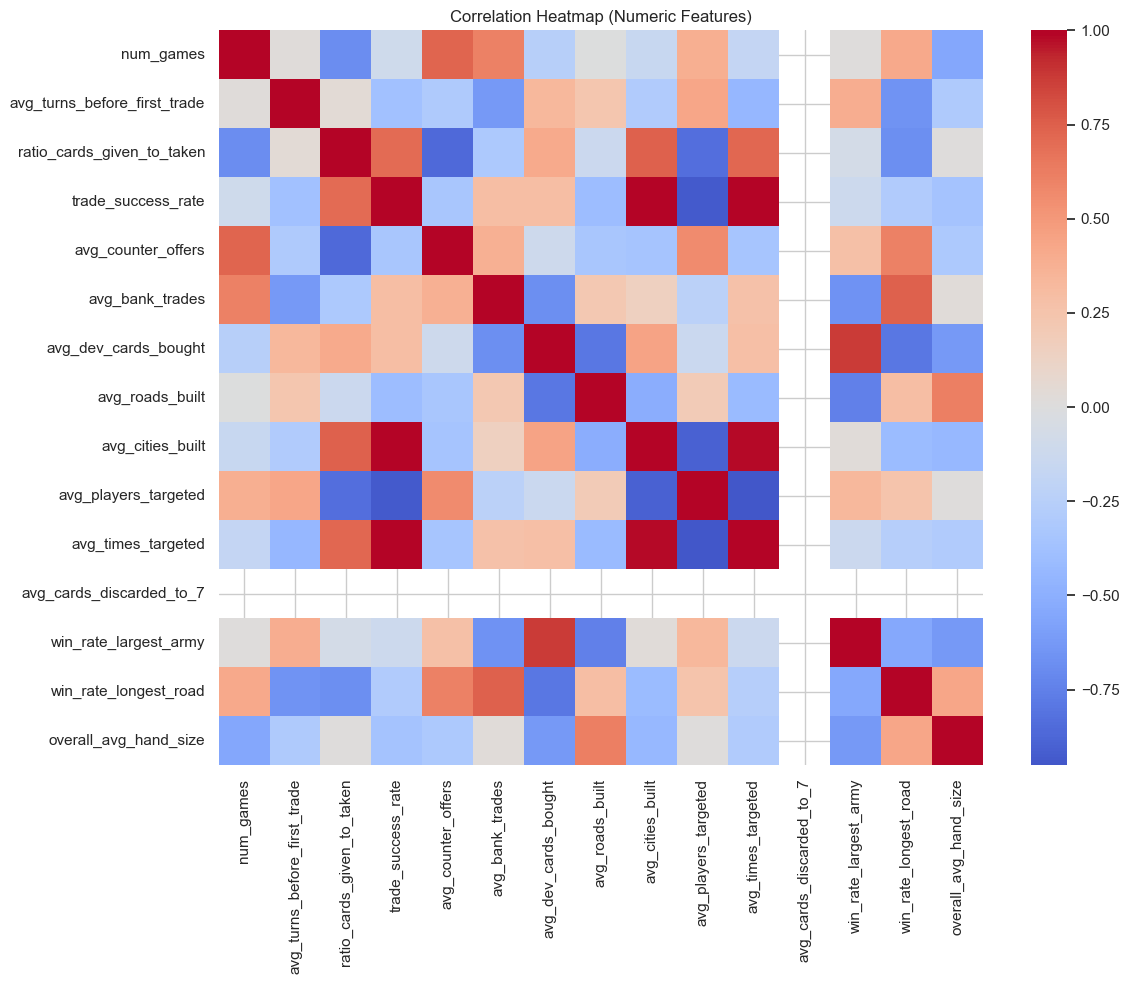

In [34]:
# C) Correlation heatmap for numeric features
if numeric_cols:
    corr_df = df_clean.select(numeric_cols).to_pandas().corr(numeric_only=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_df, cmap='coolwarm', center=0, square=False)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()


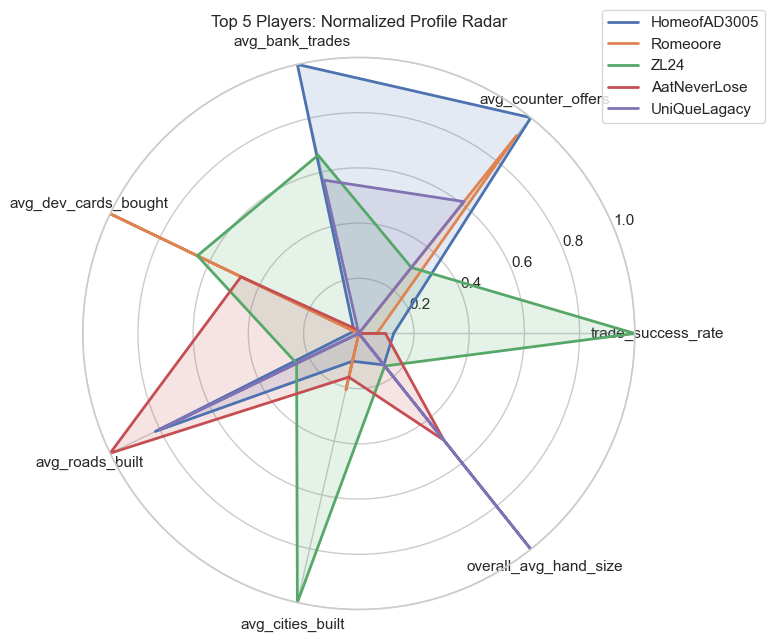

In [ ]:
# TODO: PICK THE RIGHT COLUMNS FOR THIS
radar_metrics = [
    'trade_success_rate',
    'avg_counter_offers',
    'avg_bank_trades',
    'avg_dev_cards_bought',
    'avg_roads_built',
    'avg_cities_built',
    'overall_avg_hand_size'
]

available_radar_metrics = [m for m in radar_metrics if m in plot_df.columns]
if 'num_games' in plot_df.columns and available_radar_metrics:
    top_players = plot_df.sort_values('num_games', ascending=False).head(5).copy()

    # Normalize each metric to [0,1] for fair radar comparison
    for metric in available_radar_metrics:
        min_val = top_players[metric].min()
        max_val = top_players[metric].max()
        if max_val == min_val:
            top_players[f'{metric}__norm'] = 0.0
        else:
            top_players[f'{metric}__norm'] = (top_players[metric] - min_val) / (max_val - min_val)

    norm_metrics = [f'{m}__norm' for m in available_radar_metrics]
    angles = np.linspace(0, 2 * np.pi, len(available_radar_metrics), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for _, row in top_players.iterrows():
        values = [row[m] for m in norm_metrics]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=row['player'])
        ax.fill(angles, values, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_radar_metrics)
    ax.set_ylim(0, 1)
    ax.set_title('Top 5 Players: Normalized Profile Radar')
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
    plt.tight_layout()
    plt.show()
